# Vulnerability Scanner — GOApy's phased discovery as GOAP

A Tier 2 tutorial that GOAPifies the
[vuln_scanner example](https://github.com/leopepe/GOApy/tree/master/examples/vuln_scanner)
from GOApy. The original walks `nmap` and `nikto` shell scripts through
discovery, port fingerprinting and vulnerability scanning. LangGOAP
does the same thing with an explicit GOAP plan where every phase is an
`ActionSpec` with real preconditions and effects, against an in-memory
simulated network so the notebook is hermetic.

This tutorial spotlights four planning features at once:

1. **Phased sequencing** — `discover_hosts → probe_ports → assess →
   generate_report` only assembles in one order because each phase
   preconditions on the previous one's effect flag.
2. **Sensor-driven world state** — every scan action plays the role of
   a GOApy *sensor*: it observes the simulated network and writes the
   new facts back as effects so downstream actions can read them.
3. **Replanning on a noisy probe** — a cheap `probe_ports_aggressive`
   action raises `BlockedByIDSError` against the simulated intrusion
   detection system. The executor blacklists it and replanning falls
   back on the more expensive `probe_ports_stealth`.
4. **`effect_validator` as a soundness check** — `generate_report`
   ships with a validator that rejects empty finding sets, illustrating
   how postcondition checks complement preconditions and declared
   effects.

Nothing in this notebook touches a real network. The `SimulatedNetwork`
fixture is the only source of truth for hosts, open ports and CVE
matches.

In [1]:
import logging

# The aggressive-probe action deliberately raises so the executor
# blacklists it and the planner can replan; silence the expected
# warning so the notebook output stays clean.
logging.getLogger('langgoap').setLevel(logging.ERROR)

from langgoap import GoapGraph
from tutorial_examples.data.vulnerability_scanner_instance import (
    CVE_CATALOG,
    EXPECTED_DISCOVERED_HOSTS,
    EXPECTED_FINDINGS,
    EXPECTED_SEVERITY_TOTALS,
    HOSTS,
)
from tutorial_examples.vulnerability_scanner import (
    SimulatedNetwork,
    vulnerability_scanner_actions,
    vulnerability_scanner_goal,
    vulnerability_scanner_start,
)

print(f'Hosts on simulated subnet: {len(HOSTS)}')
for host in HOSTS:
    state = 'up  ' if host.is_up else 'down'
    ports = ','.join(str(p) for p in host.open_ports) or '-'
    print(f'  {host.ip:<14s}  {host.hostname:<10s}  {state}  ports={ports}')

Hosts on simulated subnet: 5
  192.168.1.10    web01       up    ports=80,443
  192.168.1.20    db01        up    ports=5432
  192.168.1.30    files01     up    ports=22,445
  192.168.1.40    mail01      up    ports=25,587
  192.168.1.50    legacy01    down  ports=-


## 1. The CVE catalog and the expected report

Three of the four reachable hosts run a service that has a known
vulnerability in our hand-curated catalog. The expected `findings`
list and per-severity totals are deterministic:

In [2]:
print('CVE catalog:')
for port, cve in sorted(CVE_CATALOG.items()):
    print(f'  port {port:<5d}  {cve.id:<16s}  {cve.severity:<8s}  {cve.service}')

print()
print('Expected findings:')
for host, cve, severity in EXPECTED_FINDINGS:
    print(f'  {host:<14s}  {cve:<16s}  {severity}')

print()
print(f'Severity totals : {EXPECTED_SEVERITY_TOTALS}')

CVE catalog:
  port 25     CVE-2024-39929    critical  Exim SMTP
  port 80     CVE-2023-44487    high      HTTP/2 Rapid Reset
  port 5432   CVE-2024-7348     high      PostgreSQL

Expected findings:
  192.168.1.10    CVE-2023-44487    high
  192.168.1.20    CVE-2024-7348     high
  192.168.1.40    CVE-2024-39929    critical

Severity totals : {'critical': 1, 'high': 2, 'medium': 0, 'low': 0}


## 2. The action catalog

Five actions model the classic phased-discovery loop. Every action
plays the role of a GOApy *sensor*: in addition to flipping a boolean
effect flag, it writes back the data it observed (`hosts`,
`host_ports`, `findings`, `report`) so downstream actions can read
what previous phases discovered. Sensor side-effects do **not** appear
in `ActionSpec.effects` — those keys are only the planning predicates
A\* reasons about — but they are merged into world state by the
executor when the action returns.

| Action | Precondition | Effect (planning) | Sensor side-effects (world state) | Cost | Notes |
|--------|-------------|-------------------|------------------------------------|------|-------|
| `discover_hosts` | `hosts_discovered=False` | `hosts_discovered=True` | `hosts: list[str]` | 1 | Lists reachable hosts |
| `probe_ports_aggressive` | `hosts_discovered=True`, `ports_scanned=False` | `ports_scanned=True` | `host_ports: dict[str, list[int]]`, `scan_method="aggressive"` | 2 | Fast SYN scan — **blocked by IDS** |
| `probe_ports_stealth` | `hosts_discovered=True`, `ports_scanned=False` | `ports_scanned=True` | `host_ports: dict[str, list[int]]`, `scan_method="stealth"` | 5 | Slow stealth scan, always works |
| `assess_vulnerabilities` | `ports_scanned=True`, `vulns_assessed=False` | `vulns_assessed=True` | `findings: list[dict]` | 3 | CVE catalog lookup |
| `generate_report` | `vulns_assessed=True`, `report_generated=False` | `report_generated=True` | `report: dict` | 1 | Aggregation + `effect_validator` |

The cost delta between `probe_ports_aggressive` (2) and
`probe_ports_stealth` (5) is the whole story: A\* prefers the cheap
aggressive path (total cost 7) and only falls back on the stealth
draft after the aggressive one fails at runtime.

In [3]:
network = SimulatedNetwork()
actions = vulnerability_scanner_actions(network)
for a in actions:
    validator = 'yes' if a.effect_validator is not None else 'no'
    print(f'  {a.name:<26s}  pre={dict(a.preconditions)}  eff={dict(a.effects)}  cost={a.cost}  validator={validator}')

  discover_hosts              pre={'hosts_discovered': False}  eff={'hosts_discovered': True}  cost=1.0  validator=no
  probe_ports_aggressive      pre={'hosts_discovered': True, 'ports_scanned': False}  eff={'ports_scanned': True}  cost=2.0  validator=no
  probe_ports_stealth         pre={'hosts_discovered': True, 'ports_scanned': False}  eff={'ports_scanned': True}  cost=5.0  validator=no
  assess_vulnerabilities      pre={'ports_scanned': True, 'vulns_assessed': False}  eff={'vulns_assessed': True}  cost=3.0  validator=no
  generate_report             pre={'vulns_assessed': True, 'report_generated': False}  eff={'report_generated': True}  cost=1.0  validator=yes


### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

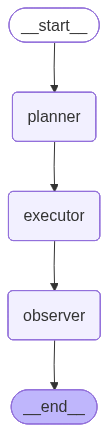

In [4]:
from IPython.display import Image, display

graph = GoapGraph(actions=actions)
display(Image(graph.compile().get_graph().draw_mermaid_png()))

## 3. Plan the cheap path

A\* doesn't know the aggressive scan will be blocked — cost is all it
sees. The initial plan is
`discover_hosts → probe_ports_aggressive → assess_vulnerabilities →
generate_report` at total cost 7.

In [5]:
from langgoap.planner.astar import plan as astar_plan
from langgoap.state import PlanningState

initial_plan = astar_plan(
    PlanningState.from_dict(vulnerability_scanner_start()),
    vulnerability_scanner_goal(),
    actions,
)
print('Initial plan:')
for step, a in enumerate(initial_plan.actions, start=1):
    print(f'  {step}. {a.name}  (cost {a.cost})')
print(f'Total cost: {initial_plan.total_cost}')

Initial plan:
  1. discover_hosts  (cost 1.0)
  2. probe_ports_aggressive  (cost 2.0)
  3. assess_vulnerabilities  (cost 3.0)
  4. generate_report  (cost 1.0)
Total cost: 7.0


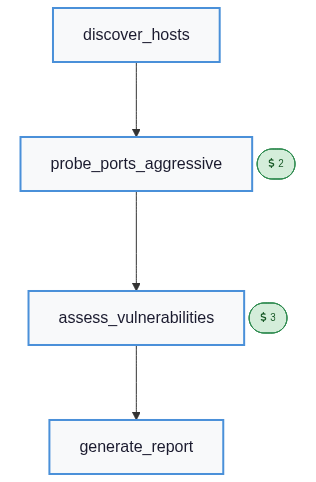

In [6]:
display(Image(initial_plan.draw_mermaid_png()))

## 4. Run the full GOAP loop against the IDS-protected network

Running the plan exercises the whole loop — executor, observer,
blacklist, replanner — against the simulated network we just built.
The aggressive probe raises `BlockedByIDSError`, the executor catches
the exception and adds the action to the blacklist, then the planner
rebuilds the plan around `probe_ports_stealth`.

In [7]:
graph = GoapGraph(actions=actions)
result = graph.invoke(
    goal=vulnerability_scanner_goal(),
    world_state=vulnerability_scanner_start(),
)

print(f'Status      : {result["status"]}')
print(f'Replans     : {result.get("replan_count", 0)}')
print(f'Blacklisted : {list(result.get("blacklisted_actions", []))}')
print()
print('Execution history:')
for h in result['execution_history']:
    status = 'OK' if h.success else f'FAIL ({h.error})'
    print(f'  {h.action_name:<26s}  {status}')

Status      : goal_achieved
Replans     : 1
Blacklisted : ['probe_ports_aggressive']

Execution history:
  discover_hosts              OK
  probe_ports_aggressive      FAIL (intrusion detection system blocked aggressive scan)
  probe_ports_stealth         OK
  assess_vulnerabilities      OK
  generate_report             OK


## 5. The report the agent actually returned

On success the executor stores the discovered hosts, the per-host port
map and the aggregated vulnerability report in world state under
`hosts`, `host_ports` and `report`. The observer checks
`report_generated=True` and routes to the terminal node.

In [8]:
ws = result['world_state']
report = ws['report']

print(f'Hosts discovered : {ws["hosts"]}')
print(f'Scan method used : {ws["scan_method"]}')
print()
print(f'Findings ({len(report["findings"])}):')
for finding in report['findings']:
    print(
        f'  {finding["host"]:<14s}  port {finding["port"]:<5d}  '
        f'{finding["cve"]:<16s}  {finding["severity"]:<8s}  {finding["service"]}'
    )
print()
print(f'Severity totals  : {report["severity_totals"]}')

Hosts discovered : ['192.168.1.10', '192.168.1.20', '192.168.1.30', '192.168.1.40']
Scan method used : stealth

Findings (3):
  192.168.1.10    port 80     CVE-2023-44487    high      HTTP/2 Rapid Reset
  192.168.1.20    port 5432   CVE-2024-7348     high      PostgreSQL
  192.168.1.40    port 25     CVE-2024-39929    critical  Exim SMTP

Severity totals  : {'critical': 1, 'high': 2, 'medium': 0, 'low': 0}


## 6. The `effect_validator` soundness check

`generate_report` ships with a validator that rejects *empty* finding
sets. Running the same action against an empty network exercises the
failure branch — the executor would mark the action failed and
replanning would take over. We drive the validator directly here so
the pattern is visible without depending on the internal
action-failed machinery:

In [9]:
empty_network = SimulatedNetwork(hosts=(), ids_active=False)
empty_actions = {a.name: a for a in vulnerability_scanner_actions(empty_network)}
report_action = empty_actions['generate_report']

ws = {
    'hosts_discovered': True,
    'ports_scanned': True,
    'vulns_assessed': True,
    'report_generated': False,
    'hosts': [],
    'host_ports': {},
    'findings': [],
}
raw = report_action.execute(ws)
post = {**ws, **raw}
# Pass the actual pre-state ws (not an empty dict) so the validator
# sees the same inputs the executor would feed it.
print(f'Findings returned : {raw["report"]["findings"]}')
print(f'Validator verdict : {report_action.validate_effects(ws, post)}')

Findings returned : []
Validator verdict : False


`False` from the validator tells the executor the action did not
actually accomplish what it claimed, triggering the same blacklist +
replan dance that `probe_ports_aggressive` used in the happy-path run
above.

## 7. Natural-language intake

As with the other Tier 2 tutorials, LangGOAP can take a plain English
request and turn it into a `GoalSpec` via `GoalInterpreter`. For a
runnable notebook we use `FakeStructuredModel` so there is no API key
dependency — swap in `ChatOpenAI`, `ChatAnthropic`, or any
`BaseChatModel` subclass in production.

In [10]:
from langgoap import GoalInterpreter, InterpretedGoal
from langgoap.testing import FakeStructuredModel

llm = FakeStructuredModel(
    response=InterpretedGoal(
        conditions={'report_generated': True},
        constraints=[],
        objectives=[],
        reasoning='The operator wants a vulnerability report, so report_generated must be True.',
    )
)

nl_actions = vulnerability_scanner_actions(SimulatedNetwork())
nl_result = GoapGraph(actions=nl_actions).invoke_nl(
    'Scan the local network and tell me what vulnerabilities you find.',
    llm=llm,
    world_state=vulnerability_scanner_start(),
)

print(f'Status : {nl_result["status"]}')
print(f'Severity totals : {nl_result["world_state"]["report"]["severity_totals"]}')
for finding in nl_result['world_state']['report']['findings']:
    print(
        f'  {finding["host"]:<14s}  {finding["cve"]:<16s}  {finding["severity"]}'
    )

Status : goal_achieved
Severity totals : {'critical': 1, 'high': 2, 'medium': 0, 'low': 0}
  192.168.1.10    CVE-2023-44487    high
  192.168.1.20    CVE-2024-7348     high
  192.168.1.40    CVE-2024-39929    critical


## Summary

Five actions, one simulated IDS and a tiny CVE catalog are enough to
demonstrate the GOApy phased-discovery story end-to-end inside
LangGOAP:

- **Sequencing** falls out of preconditions — no action can fire
  before the previous phase has set its effect flag, mirroring how
  GOApy's `active_http_servers.sh` re-invokes `list_active_nodes.sh`
  when the prerequisite file is missing.
- **Sensor-driven state** lets each scan action announce what it saw
  (hosts, ports, findings) so downstream phases can consume it without
  any sidecar bookkeeping.
- **Blacklisting** turns a one-off `BlockedByIDSError` into a planning
  signal without the user having to catch anything.
- **`effect_validator`** acts as a belt-and-braces soundness check for
  actions whose success can only be verified after the fact — "the
  scan ran" is not the same as "the scan found something worth
  reporting".

The integration test that pins this tutorial lives at
`tests/integration/test_vulnerability_scanner.py`.